# Notebook 6 (v2) — Ablation Experiment: EfficientNet-B0 + Transfer Learning

ניסוי השוואתי לנוטבוק 05 (Baseline: ResNet50).
מטרת הניסוי: לבדוק האם ארכיטקטורה שונה (EfficientNet-B0) משפרת/מרעה את הביצועים בהשוואה ל-ResNet50, תחת אותה שיטת אימון (Transfer Learning + Frozen Backbone + Augmentation על Train בלבד).

**הערה על תיקונים מול הגרסה הקודמת של נוטבוק זה:**
- המודל נטען עם משקלים מאומנים (`weights=...DEFAULT`) *לפני* לולאת האימון, לא אחריה.
- אין תאי דיבוג כפולים.
- ה-Confusion Matrix מחושב על כל ה-Test Set (אין `break` שעוצר אחרי batch ראשון).
- נוספה מדידת Val Loss (לא רק Train Loss) כדי לעמוד בדרישת ה-Learning Curves של המטלה.


## 1. ייבוא ספריות והגדרת SSL (לפני כל הורדת משקלים)

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image
from sklearn.metrics import confusion_matrix


## 2. טעינת הנתונים (אותם קבצים כמו בנוטבוק 05, לצורך השוואה הוגנת)

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df = pd.read_csv("../data/processed/test.csv")
clean_df = pd.read_csv("../data/processed/clean_metadata.csv")

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))


Train: 8400 | Val: 1800 | Test: 1801


In [3]:
platforms = sorted(clean_df["platform"].unique())
label_map = {platform: idx for idx, platform in enumerate(platforms)}
print(label_map)


{'Apple': 0, 'Facebook': 1, 'Google': 2, 'JoyPixels': 3, 'Samsung': 4, 'Twitter': 5, 'Windows': 6}


## 3. Data Augmentation

Augmentation מיושם **רק** על Train. Validation ו-Test עוברים אך ורק Resize + ToTensor, בהתאם לדרישת המטלה.

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


## 4. Dataset ו-DataLoaders

In [5]:
class EmojiDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = f"../data/processed/{row['platform']}/{row['file_name']}"
        image = Image.open(image_path).convert("RGB")
        label = label_map[row["platform"]]

        if self.transform:
            image = self.transform(image)

        return image, label


In [6]:
train_dataset = EmojiDataset(train_df, transform=train_transform)
val_dataset = EmojiDataset(val_df, transform=eval_transform)
test_dataset = EmojiDataset(test_df, transform=eval_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Loaders ready:", len(train_loader), "train batches |", len(val_loader), "val batches |", len(test_loader), "test batches")


Loaders ready: 263 train batches | 57 val batches | 57 test batches


In [7]:
# בדיקת שפיות מהירה - לא חובה להריץ שוב אחרי שעבד פעם אחת
images, labels = next(iter(train_loader))
print(images.shape, labels[:10])


C:\Users\chagitmi\AppData\Local\Programs\Python\Python314\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


torch.Size([32, 3, 224, 224]) tensor([3, 2, 0, 6, 1, 5, 5, 0, 6, 3])


## 5. המודל — EfficientNet-B0 (Transfer Learning)

בניגוד לנוטבוק 05 (ResNet50), כאן נשתמש ב-EfficientNet-B0 — ארכיטקטורה קלה ויעילה יותר, כדי לבסס Ablation Study אמיתי בין שתי ארכיטקטורות שונות תחת אותה שיטת אימון.

**חשוב:** המשקלים המאומנים נטענים כאן, *לפני* שממשיכים ללולאת האימון — זה בדיוק התיקון לבאג שהיה בגרסה הקודמת.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Freeze the backbone - רק ה-Classifier יתאמן, בדיוק כמו בנוטבוק 05
for param in model.parameters():
    param.requires_grad = False

# EfficientNet-B0 classifier head: Sequential(Dropout, Linear(1280, 1000))
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(label_map))

model = model.to(device)
print(model.classifier)


Device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\chagitmi/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:05<00:00, 3.62MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)


## 6. לולאת אימון

**לפני הרצה על כל ה-Epochs:** מומלץ להריץ קודם עם `EPOCHS = 1` כדי למדוד כמה זמן לוקח Epoch בודד על המחשב שלך (במיוחד אם רצים על CPU), ולפי זה להחליט אם להגדיל ל-3 Epochs (כמו ה-Baseline, לצורך השוואה הוגנת) או להשאיר פחות.

In [10]:
EPOCHS = 3  # זהה למספר ה-Epochs בנוטבוק 05, לצורך השוואה הוגנת. שני/י ל-1 לבדיקת זמן ריצה קודם.

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # ---------------- TRAIN ----------------
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ---------------- VALIDATION ----------------
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    elapsed = time.time() - epoch_start
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")


Epoch 1/3 | Train Loss: 1.0581 | Train Acc: 0.6556 | Val Loss: 0.7481 | Val Acc: 0.7689 | Time: 660.7s
Epoch 2/3 | Train Loss: 0.7144 | Train Acc: 0.7585 | Val Loss: 0.6317 | Val Acc: 0.7889 | Time: 681.9s
Epoch 3/3 | Train Loss: 0.6505 | Train Acc: 0.7720 | Val Loss: 0.6026 | Val Acc: 0.7978 | Time: 698.2s


## 7. Learning Curves

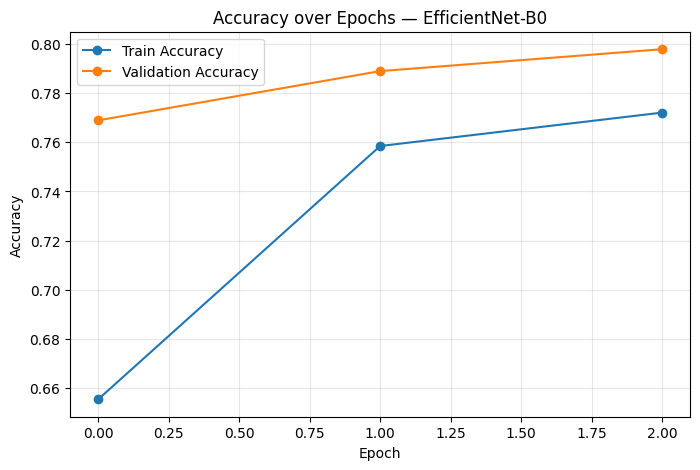

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy", marker="o")
plt.plot(val_accs, label="Validation Accuracy", marker="o")
plt.legend()
plt.title("Accuracy over Epochs — EfficientNet-B0")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.show()


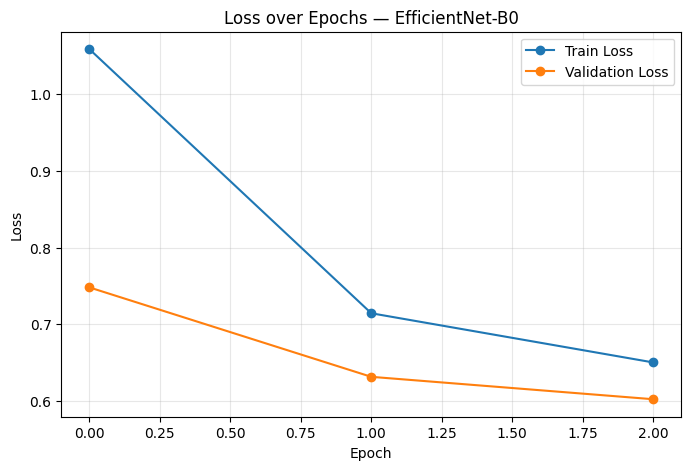

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="o")
plt.legend()
plt.title("Loss over Epochs — EfficientNet-B0")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()


## 8. הערכה על Test Set

In [13]:
model.eval()
test_correct, test_total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = test_correct / test_total
print(f"Test Accuracy (EfficientNet-B0): {test_acc:.4f}")


Test Accuracy (EfficientNet-B0): 0.7857


## 9. Confusion Matrix (Normalized)

**תיקון מרכזי מול הגרסה הקודמת:** אין `break` בלולאה — כל ה-Test Set נאסף לפני חישוב המטריצה.

Total predictions collected: 1801


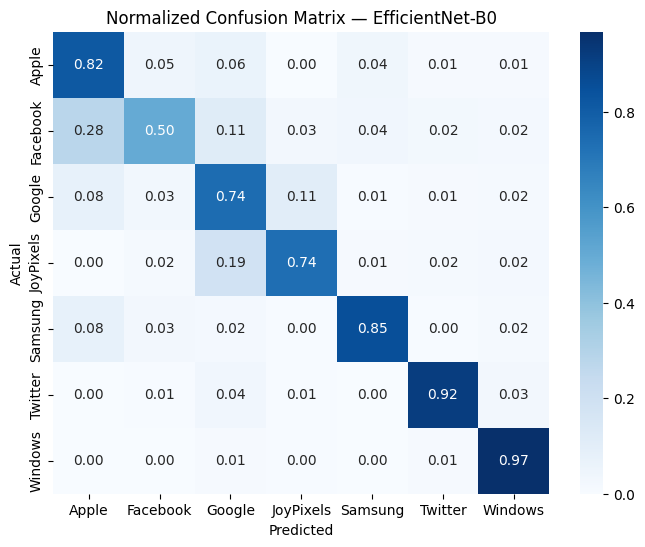

In [14]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Total predictions collected:", len(all_preds))  # צריך להיות שווה לגודל ה-Test Set

cm = confusion_matrix(all_labels, all_preds, normalize="true")

class_names = [name for name, idx in sorted(label_map.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix — EfficientNet-B0")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 10. Class Distribution (Train Set)

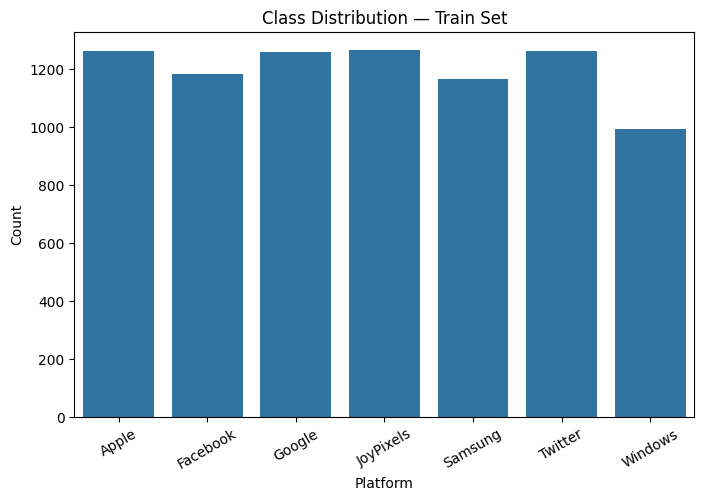

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x="platform", data=train_df, order=sorted(train_df["platform"].unique()))
plt.title("Class Distribution — Train Set")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


## 11. סיכום להשוואה מול נוטבוק 05 (Ablation Study)

**חשוב:** יש להשלים כאן את המספרים בפועל מנוטבוק 05 (ה-Baseline) לאחר שתריצי אותו במלואו, ולעדכן את `baseline_test_acc` בהתאם — הערך הנוכחי הוא Placeholder.

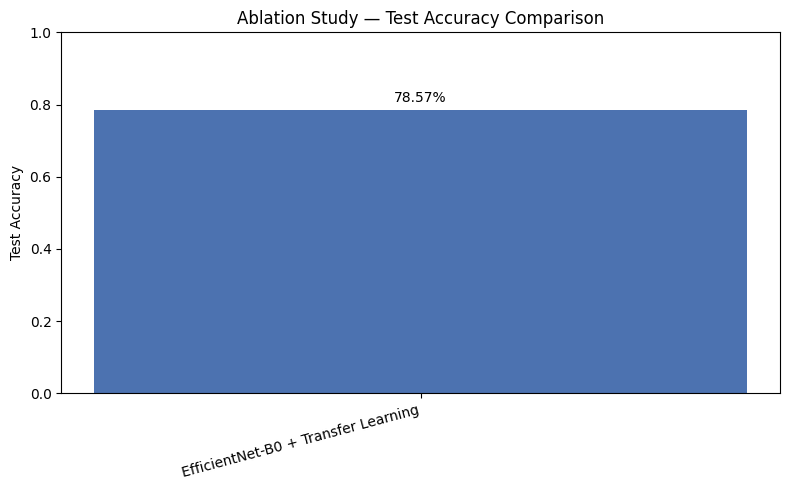

In [16]:
# TODO: לעדכן את הערכים לפי תוצאות אמיתיות מכל נוטבוק
experiments = {
    "Baseline (ResNet50, no augmentation)": None,       # למלא מנוטבוק 05
    "ResNet50 + Augmentation": None,                     # אם קיים ניסוי כזה בנפרד
    "EfficientNet-B0 + Transfer Learning": test_acc,      # מהריצה הנוכחית
}

# הצגה רק של ניסויים שכבר יש להם ערך
valid_experiments = {k: v for k, v in experiments.items() if v is not None}

plt.figure(figsize=(8, 5))
plt.bar(valid_experiments.keys(), valid_experiments.values(), color=["#4C72B0", "#DD8452", "#55A868"][:len(valid_experiments)])
plt.title("Ablation Study — Test Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
for i, (name, acc) in enumerate(valid_experiments.items()):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha="center")
plt.tight_layout()
plt.show()
